In [ ]:
import pandas as pd
data = pd.read_csv("AB_NYC_2019.csv")

In [ ]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
missing_values = data.isnull().sum()
print(missing_values)

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [ ]:
colsToDrop = ["id", "host_name", "last_review", "reviews_per_month"]
data.drop(colsToDrop, axis = 1)

,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Clean & quiet apt home by the park,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,Skylit Midtown Castle,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,THE VILLAGE OF HARLEM....NEW YORK !,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,Cozy Entire Floor of Brownstone,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Entire Apt: Spacious Studio/Loft by central park,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
48890,Charming one bedroom - newly renovated rowhouse,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,2,9
48891,Affordable room in Bushwick/East Williamsburg,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,2,36
48892,Sunny Studio at Historical Neighborhood,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,1,27
48893,43rd St. Time Square-cozy single bed,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,6,2


In [ ]:
data["price"].fillna(data["price"].mean())

,price
0,149
1,225
2,150
3,89
4,80
...,...
48890,70
48891,40
48892,115
48893,55


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='price'>

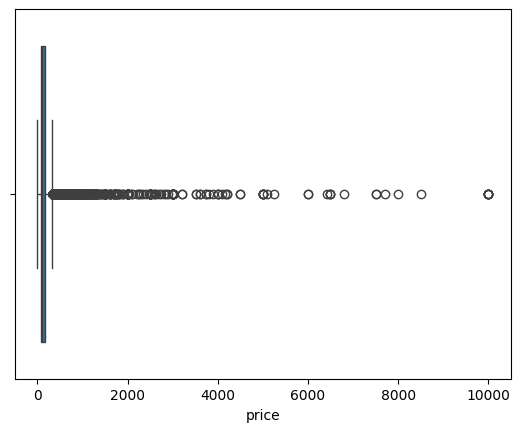

In [ ]:
sns.boxplot(x="price", data = data)

In [ ]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
data_cleaned = data[(data['price'] >= lower_bound) & (data['price'] <= upper_bound)]

print(data_cleaned)

             id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
48891  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
48892  36485431            Sunny Studio at Historical Neighborhood  23492952   
48893  36485609               43rd St. Time Square-cozy single bed  30985759   
48894  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

           host_name neighbourhood_grou

<Axes: xlabel='price'>

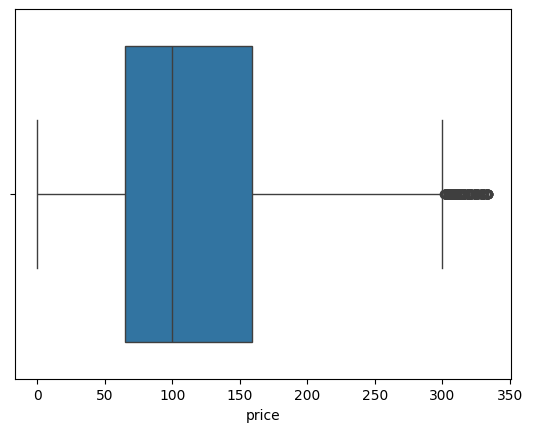

In [ ]:
# Box plot for cleaned data
sns.boxplot(x=data_cleaned['price'])

<Axes: xlabel='price'>

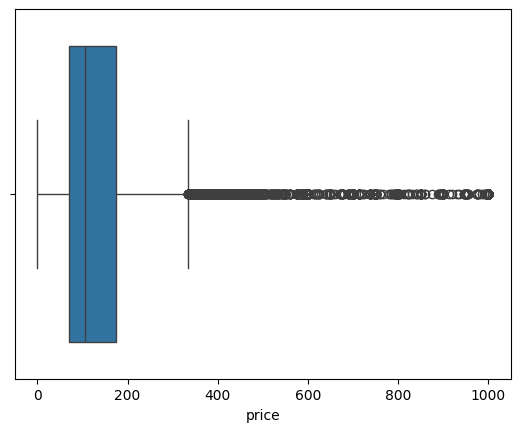

In [ ]:
#Winsorization
lowerbound = 0
upperbound = 1000

data["price"] = data["price"].apply(lambda x: lowerbound if x < lowerbound else upperbound if x > upperbound else x)

sns.boxplot(x=data["price"])

<Axes: xlabel='price'>

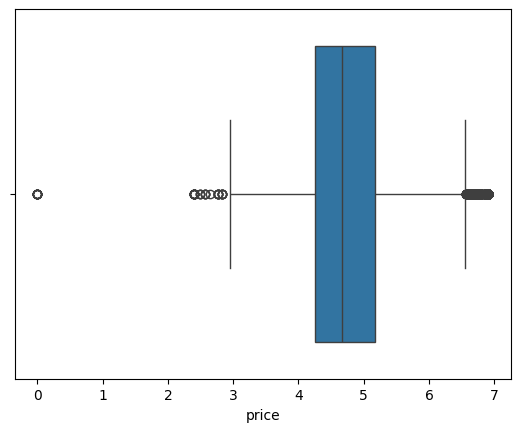

In [ ]:
import numpy as np
data["price"] = np.log(data["price"] + 1)

import seaborn as sns

sns.boxplot(x=data["price"])

In [ ]:
# Perform one-hot encoding
encoded_data = pd.get_dummies(data, columns=['room_type'])

#Display by forcing pandas to return integers instead of booleans
encoded_data = pd.get_dummies(data, columns=['room_type'], dtype=int)
encoded_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,5.010635,1,9,2018-10-19,0.21,6,365,0,1,0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,5.420535,1,45,2019-05-21,0.38,2,355,1,0,0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,5.017280,3,0,NaN,NaN,1,365,0,1,0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,4.499810,1,270,2019-07-05,4.64,1,194,1,0,0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,4.394449,10,9,2018-11-19,0.10,1,0,1,0,0


In [ ]:
import pandas as pd
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# One-hot encode the selected columns
columns_to_encode = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea", "furnishingstatus"]
df = pd.get_dummies(df, columns=columns_to_encode, dtype=int)

# Display the encoded DataFrame
print(df)

        price  area  bedrooms  bathrooms  stories  parking  mainroad_no  \
0    13300000  7420         4          2        3        2            0   
1    12250000  8960         4          4        4        3            0   
2    12250000  9960         3          2        2        2            0   
3    12215000  7500         4          2        2        3            0   
4    11410000  7420         4          1        2        2            0   
..        ...   ...       ...        ...      ...      ...          ...   
540   1820000  3000         2          1        1        2            0   
541   1767150  2400         3          1        1        0            1   
542   1750000  3620         2          1        1        0            0   
543   1750000  2910         3          1        1        0            1   
544   1750000  3850         3          1        2        0            0   

     mainroad_yes  guestroom_no  guestroom_yes  ...  basement_yes  \
0               1             

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,0,1,1,0,...,0,1,0,0,1,0,1,1,0,0
1,12250000,8960,4,4,4,3,0,1,1,0,...,0,1,0,0,1,1,0,1,0,0
2,12250000,9960,3,2,2,2,0,1,1,0,...,1,1,0,1,0,0,1,0,1,0
3,12215000,7500,4,2,2,3,0,1,1,0,...,1,1,0,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,0,1,0,1,...,1,1,0,0,1,1,0,1,0,0


In [ ]:
from sklearn.linear_model import LinearRegression
# Extract features (X) and target (y)
X = df["area"].values.reshape(-1, 1)  # Reshape to 2D
y = df["price"].values.reshape(-1, 1) # Reshape to 2D

# Train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Predict house price for a given square footage
import numpy as np

sq_ft = np.array([[8000]])  # Example: Predict price for 8000 sq ft
predicted_price = model.predict(sq_ft)

# Output result
print(f"Predicted house price for {sq_ft[0][0]} sq ft: {predicted_price[0][0]:,.2f}")

Predicted house price for 8000 sq ft: 6,083,107.64


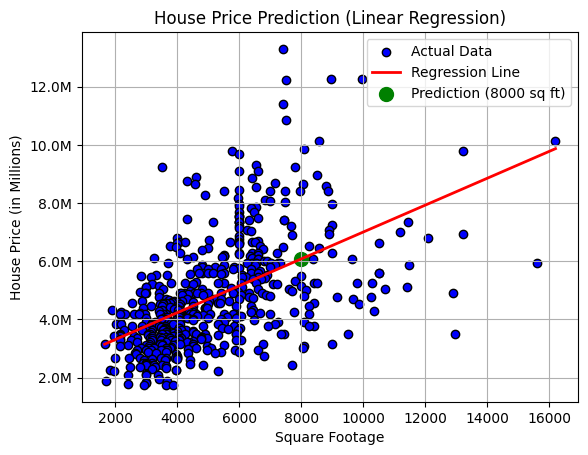

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick  # Import ticker for formatting

# Extract features (X) and target (y)
X = df["area"].values.reshape(-1, 1)  # Reshape to 2D
y = df["price"].values.reshape(-1, 1) # Reshape to 2D

# Train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Predict house price for a given square footage
sq_ft = np.array([[8000]])  # Predict price for 8000 sq ft
predicted_price = model.predict(sq_ft)

# Generate predictions for visualization
X_range = np.linspace(min(X), max(X), 100).reshape(-1, 1)  # Create smooth X values
y_pred = model.predict(X_range)  # Predict y values

# Plot actual data points
plt.scatter(X, y, color='blue', label="Actual Data", edgecolor='black')

# Plot regression line
plt.plot(X_range, y_pred, color='red', linewidth=2, label="Regression Line")

# Plot the predicted price
plt.scatter(sq_ft, predicted_price, color='green', marker='o', s=100, label="Prediction (8000 sq ft)")

# Labels and title
plt.xlabel("Square Footage")
plt.ylabel("House Price (in Millions)")
plt.title("House Price Prediction (Linear Regression)")

# Format Y-axis in millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.legend()
plt.grid(True)

# Show plot
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Extract features (excluding "price")
X = df.drop(columns=["price"])  # Features
y = df["price"]  # Target variable

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ What is "random_state" and why use 42?
# - Ensures the same train-test split every time.
# - 42 is a commonly used arbitrary number in ML.

# Create & Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print Results
print("Test Set Predictions:", y_pred)
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"R² Score: {r2:.4f}")


Test Set Predictions: [5164653.90033968 7224722.29802167 3109863.24240338 4612075.32722559
 3294646.25725955 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782 9617039.50315581 2798087.30447887
 3171096.76847063 3394639.09125527 3681088.65424275 5263187.74621485
 3035963.47612384 4786122.80040051 4349551.9200572  3572362.09930451
 5774875.2139565  5886993.57919884 2730836.19518458 4727316.47323635
 5244847.52716801 7555324.21605604 3220790.84680268 5191898.79934206
 8143726.91009787 3398814.09825034 6490693.05027925 3315105.9074781
 6708457.36761326 4201738.21071676 3557571.06735186 5836974.50478626
 4808660.67448475 4362878.73613261 3191242.95701507 4596554.93225238
 4566042.86048411 3517779.52374148 7205844.79365836 3983597.27861103
 3749338.70271056 4274731.09125895 6757442.10783741 4037320.43665851
 3769334.90397126 3417627.44377156 7268416.67644612 2802534.35431384
 4341750.61420452 4516422.15345642 3679997.65037847 2678959.06481151
 7498029.1778

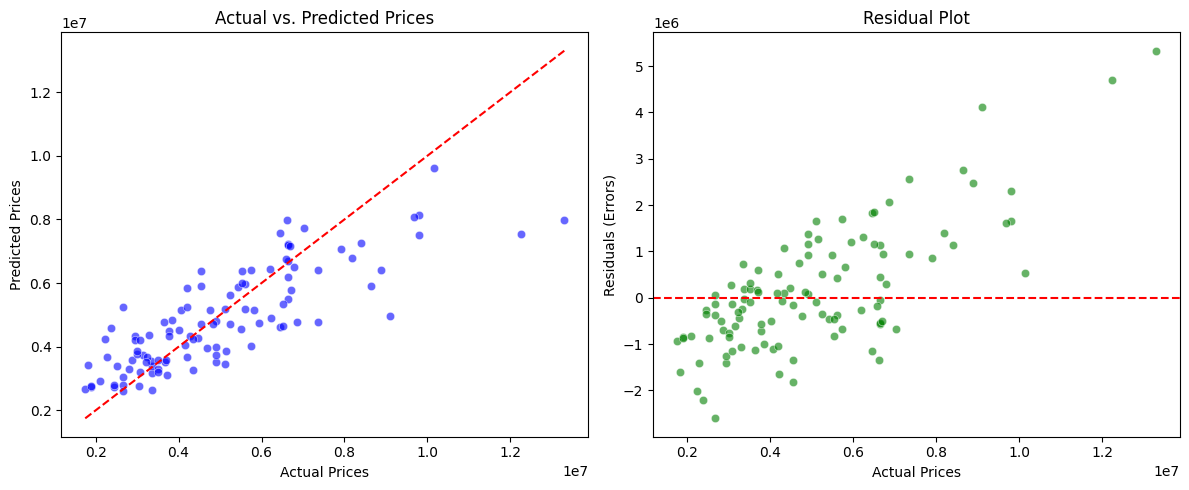

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatterplot: Actual vs. Predicted Prices
plt.figure(figsize=(12, 5))

# 🔹 Subplot 1: Actual vs. Predicted Prices
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, color="blue", alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='dashed')  # Perfect fit line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Prices")

# 🔹 Subplot 2: Residual Plot (Errors)
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.scatterplot(x=y_test, y=residuals, color="green", alpha=0.6)
plt.axhline(y=0, color='red', linestyle='dashed')  # Reference line at 0
plt.xlabel("Actual Prices")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot")

# Show plots
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load your dataset (replace with actual file path if needed)
df = pd.read_csv("Housing.csv")  # Ensure file is uploaded

# Extract features (X) and target (y)
X = df["area"].values.reshape(-1, 1)  # Reshape to 2D
y = df["price"].values.reshape(-1, 1) # Reshape to 2D

# Initialize 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores = []

# Loop through each fold
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate Mean Squared Error (MSE)
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    print(f"MSE for Fold: {mse}")

# Compute Average MSE across all folds
avg_mse = np.mean(mse_scores)
print(f"\nAverage MSE Across All Folds: {avg_mse}")

# Example: Predict house price for 8000 sq ft
sq_ft = np.array([[8000]])
predicted_price = model.predict(sq_ft)
print(f"\nPredicted Price for 8000 sq ft: {predicted_price[0][0]}")


MSE for Fold: 3675286604768.185
MSE for Fold: 3130106354946.0415
MSE for Fold: 1697444447359.1282
MSE for Fold: 1849874737457.9397
MSE for Fold: 2397962060298.9355

Average MSE Across All Folds: 2550134840966.046

Predicted Price for 8000 sq ft: 6017147.94402047


In [1]:
# Linear regression
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  # Independent variable
Y = np.array([2, 4, 5, 4, 5])  # Dependent variable

model = LinearRegression()
model.fit(X, Y)

print(f"Slope: {model.coef_[0]}, Intercept: {model.intercept_}")


Slope: 0.6, Intercept: 2.2


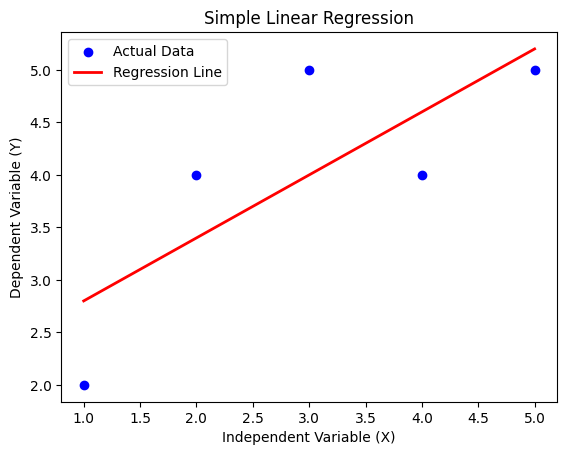

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generate sample data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2, 4, 5, 4, 5])

# Train the model
model = LinearRegression()
model.fit(X, Y)

# Predictions
Y_pred = model.predict(X)

# Visualization
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Independent Variable (X)")
plt.ylabel("Dependent Variable (Y)")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()


In [3]:
# Multiple Linear Regression
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array([[1, 2], [2, 3], [3, 5], [4, 7], [5, 11]])  # Two independent variables
Y = np.array([2, 3, 5, 4, 5])  # Dependent variable

model = LinearRegression()
model.fit(X, Y)

print(f"Coefficients: {model.coef_}, Intercept: {model.intercept_}")


Coefficients: [ 1.32857143 -0.28571429], Intercept: 1.4142857142857128


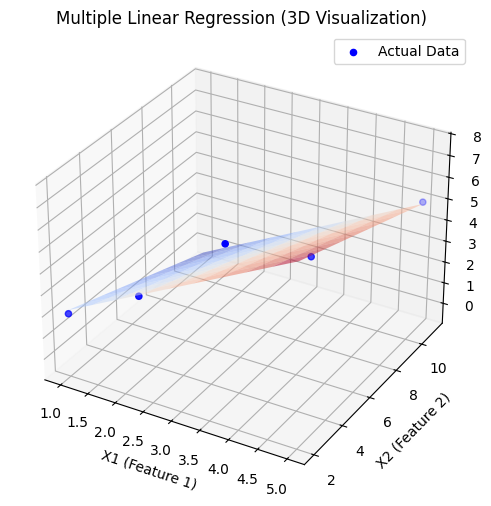

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# Generate sample data
X1 = np.array([1, 2, 3, 4, 5])
X2 = np.array([2, 3, 5, 7, 11])
Y = np.array([2, 3, 5, 4, 5])

# Combine independent variables
X = np.column_stack((X1, X2))

# Train the model
model = LinearRegression()
model.fit(X, Y)

# Generate meshgrid for 3D surface
x1_range = np.linspace(min(X1), max(X1), 10)
x2_range = np.linspace(min(X2), max(X2), 10)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)
Y_pred = model.intercept_ + model.coef_[0] * X1_grid + model.coef_[1] * X2_grid

# 3D Visualization
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of actual data
ax.scatter(X1, X2, Y, color='blue', label='Actual Data')

# Surface plot of regression plane
ax.plot_surface(X1_grid, X2_grid, Y_pred, cmap='coolwarm', alpha=0.5)

# Labels and title
ax.set_xlabel("X1 (Feature 1)")
ax.set_ylabel("X2 (Feature 2)")
ax.set_zlabel("Y (Target Variable)")
ax.set_title("Multiple Linear Regression (3D Visualization)")
ax.legend()

plt.show()


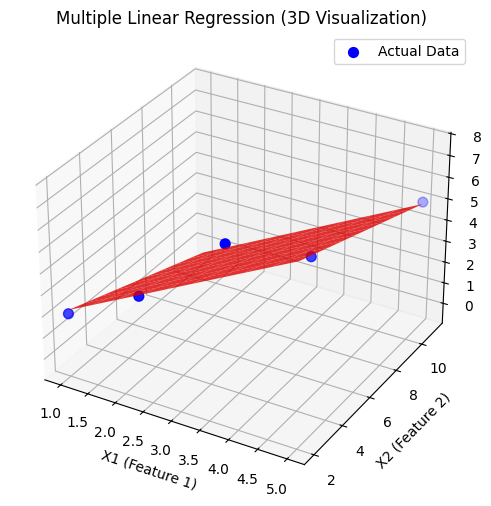

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# Generate sample data
X1 = np.array([1, 2, 3, 4, 5])
X2 = np.array([2, 3, 5, 7, 11])
Y = np.array([2, 3, 5, 4, 5])

# Combine independent variables
X = np.column_stack((X1, X2))

# Train the model
model = LinearRegression()
model.fit(X, Y)

# Generate meshgrid for 3D surface
x1_range = np.linspace(min(X1), max(X1), 10)
x2_range = np.linspace(min(X2), max(X2), 10)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)
Y_pred = model.intercept_ + model.coef_[0] * X1_grid + model.coef_[1] * X2_grid

# 3D Visualization
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of actual data
ax.scatter(X1, X2, Y, color='blue', label='Actual Data', s=50)

# Surface plot with a **bold red** color
ax.plot_surface(X1_grid, X2_grid, Y_pred, color='red', alpha=0.8)

# Labels and title
ax.set_xlabel("X1 (Feature 1)")
ax.set_ylabel("X2 (Feature 2)")
ax.set_zlabel("Y (Target Variable)")
ax.set_title("Multiple Linear Regression (3D Visualization)")
ax.legend()

plt.show()


In [ ]:
import pandas as pd
df = pd.read_csv("Housing.csv")

# One-hot encode the selected columns
columns_to_encode = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea", "furnishingstatus"]
df = pd.get_dummies(df, columns=columns_to_encode, dtype=int)

# Display the encoded DataFrame
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,0,1,1,0,...,0,1,0,0,1,0,1,1,0,0
1,12250000,8960,4,4,4,3,0,1,1,0,...,0,1,0,0,1,1,0,1,0,0
2,12250000,9960,3,2,2,2,0,1,1,0,...,1,1,0,1,0,0,1,0,1,0
3,12215000,7500,4,2,2,3,0,1,1,0,...,1,1,0,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,0,1,0,1,...,1,1,0,0,1,1,0,1,0,0


Best k: 7
Mean Absolute Error (MAE): 1314292.84
Mean Squared Error (MSE): 3337213701710.09
Root Mean Squared Error (RMSE): 1826804.23
R² Score: 0.34


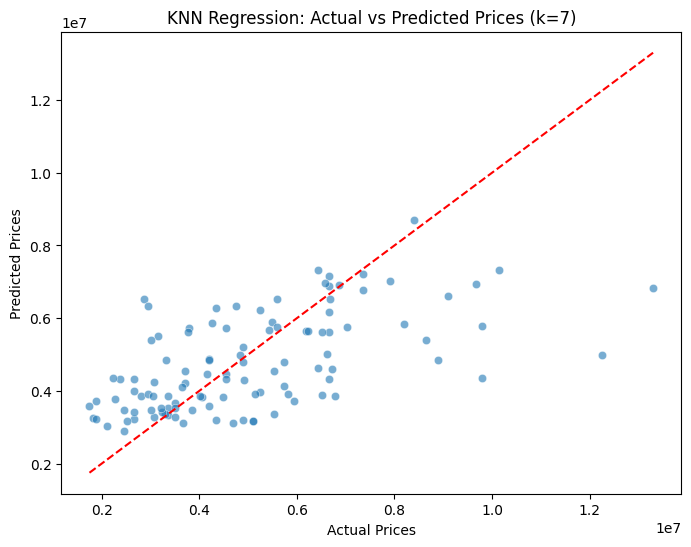

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop 'price' from features and set it as target
X = df.drop(columns=["price"])
y = df["price"]

# Split data into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter Tuning: Finding the Best k (neighbors)
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}  # Trying different values of k

knn = KNeighborsRegressor()  # Initialize Model
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring="r2", n_jobs=-1)  # 5-fold Cross Validation
grid_search.fit(X_train, y_train)

# Best parameters & best model
best_k = grid_search.best_params_["n_neighbors"]
print(f"Best k: {best_k}")

# Train KNN with Best k
best_knn = KNeighborsRegressor(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

# Make Predictions
y_pred = best_knn.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# Scatter Plot: Actual vs. Predicted Prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title(f"KNN Regression: Actual vs Predicted Prices (k={best_k})")
plt.show()


In [2]:
import pandas as pd
df = pd.read_csv("Housing.csv")

# One-hot encode the selected columns
columns_to_encode = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea", "furnishingstatus"]
df = pd.get_dummies(df, columns=columns_to_encode, dtype=int)

# Display the encoded DataFrame
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,0,1,1,0,...,0,1,0,0,1,0,1,1,0,0
1,12250000,8960,4,4,4,3,0,1,1,0,...,0,1,0,0,1,1,0,1,0,0
2,12250000,9960,3,2,2,2,0,1,1,0,...,1,1,0,1,0,0,1,0,1,0
3,12215000,7500,4,2,2,3,0,1,1,0,...,1,1,0,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,0,1,0,1,...,1,1,0,0,1,1,0,1,0,0


Mean Absolute Error: 1025824.38
Mean Squared Error: 1971426095653.93
R² Score: 0.61


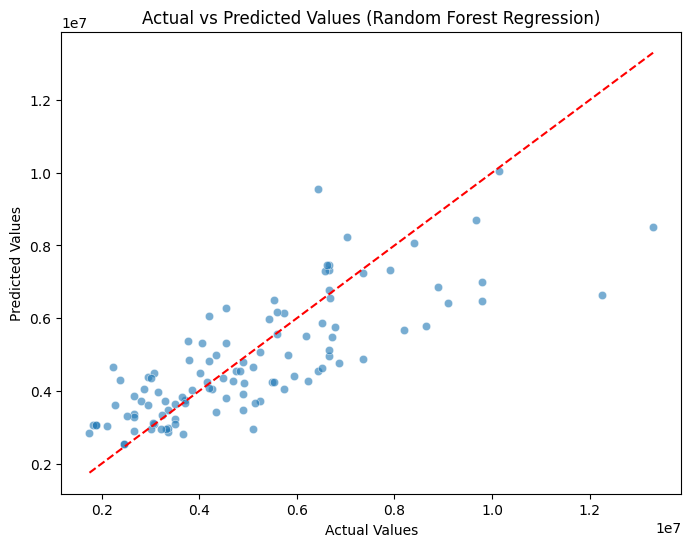

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Extract features and target variable
X = df.drop(columns=["price"])  # Features (excluding price)
y = df["price"]  # Target variable (price)

# Step 3: Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Initialize and train RandomForest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = rf_regressor.predict(X_test)

# Step 6: Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of Actual vs Predicted prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Add a reference line (ideal prediction line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

# Labels & title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Random Forest Regression)")
plt.show()


Best Parameters: {'max_depth': 15, 'n_estimators': 150}


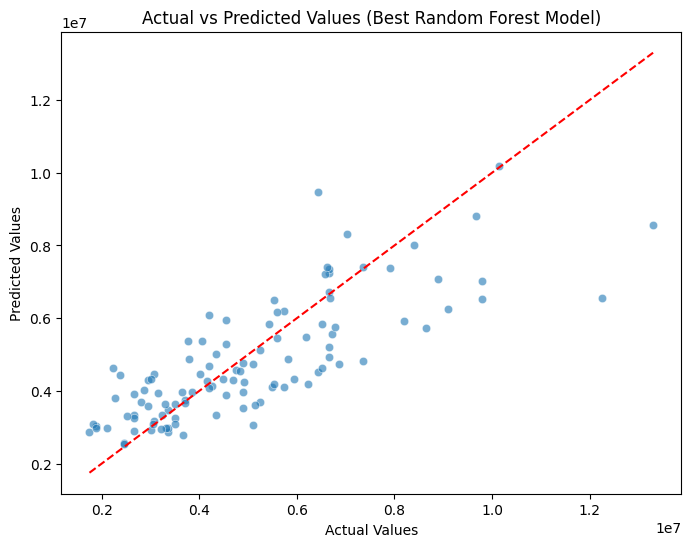

Mean Absolute Error (MAE): 1016369.89
Mean Squared Error (MSE): 1954149545404.84
Root Mean Squared Error (RMSE): 1397908.99
R² Score: 0.61


In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Extract features and target
X = df.drop(columns=["price"])  # Features (excluding price)
y = df["price"]  # Target variable

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 10, 15]
}

# Perform GridSearchCV with neg_mean_squared_error
rf_regressor = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf_regressor, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Train the best model
best_rf = RandomForestRegressor(**best_params, random_state=42)
best_rf.fit(X_train, y_train)

# Make predictions
y_pred = best_rf.predict(X_test)

# Scatter plot of Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

# Labels & title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Best Random Forest Model)")
plt.show()

# Model Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}


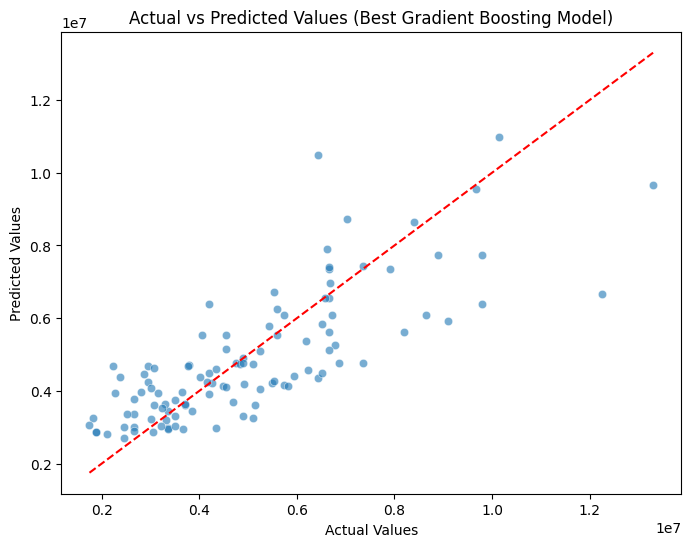

Mean Absolute Error (MAE): 1015167.84
Mean Squared Error (MSE): 1936519386197.83
Root Mean Squared Error (RMSE): 1391588.80
R² Score: 0.62


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Extract features and target
X = df.drop(columns=["price"])  # Features (excluding price)
y = df["price"]  # Target variable

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 10, 15],
    "learning_rate": [0.01, 0.1, 0.2]  # Learning rate controls step size
}

# Perform GridSearchCV with neg_mean_squared_error
gb_regressor = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gb_regressor, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Train the best model
best_gb = GradientBoostingRegressor(**best_params, random_state=42)
best_gb.fit(X_train, y_train)

# Make predictions
y_pred = best_gb.predict(X_test)

# Scatter plot of Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

# Labels & title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Best Gradient Boosting Model)")
plt.show()

# Model Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
